# Company A Telecom Churn Prevention Proposal

## Executive summary

Company A has customer, billing, usage, handset, and service-quality data for 100,000 telecom customers. This notebook develops a machine-learning system that ranks customers by their probability of churning 31–60 days after observation.

**Business recommendation:** score active customers weekly and target the highest-risk 20% with action-specific retention treatments. On the held-out test set, this segment captures approximately 30% of churners and has a churn rate around 1.5 times the portfolio average.

The final model is a probability ensemble:

- **65% engineered LightGBM**
- **35% native-categorical CatBoost ensemble**

The model is selected using validation ROC-AUC and evaluated once on an untouched 20% test set. Financial impact is presented as an illustrative scenario, not measured campaign performance.

## 1. Setup

The notebook expects the following files relative to its location:

```text
telecom/
├── Client.csv
└── Record.csv
```

Uncomment the installation command if the environment does not already contain the required packages.

In [1]:
# %pip install -q pandas numpy matplotlib seaborn scikit-learn lightgbm catboost joblib

from __future__ import annotations

import json
import warnings
from dataclasses import dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
TARGET = "churn"
ID_COLUMN = "Customer_ID"
DATA_DIR = Path("telecom")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning,
)


## 2. Load and validate the data

`Client.csv` contains account, household, handset, and demographic information. `Record.csv` contains recent usage, billing, call-quality measurements, tenure, and the churn target. Both files should contain one unique row per `Customer_ID`.

In [2]:
client = pd.read_csv(DATA_DIR / "Client.csv")
record = pd.read_csv(DATA_DIR / "Record.csv")

for name, table in (("Client.csv", client), ("Record.csv", record)):
    assert ID_COLUMN in table.columns, f"{name} is missing {ID_COLUMN}"
    assert table[ID_COLUMN].notna().all(), f"{name} contains missing customer IDs"
    assert not table[ID_COLUMN].duplicated().any(), f"{name} contains duplicate customer IDs"

df = record.merge(client, on=ID_COLUMN, how="inner", validate="one_to_one")
assert len(df) == len(client) == len(record)
assert set(df[TARGET].unique()).issubset({0, 1})

print(f"Client table: {client.shape}")
print(f"Record table: {record.shape}")
print(f"Merged analysis table: {df.shape}")
df.head()

Client table: (100000, 50)
Record table: (100000, 51)
Merged analysis table: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


## 3. Exploratory data analysis

The EDA answers four questions:

1. Is the target balanced?
2. Which fields have substantial missingness?
3. Which customer signals show directional churn risk?
4. Is a multivariate model justified?

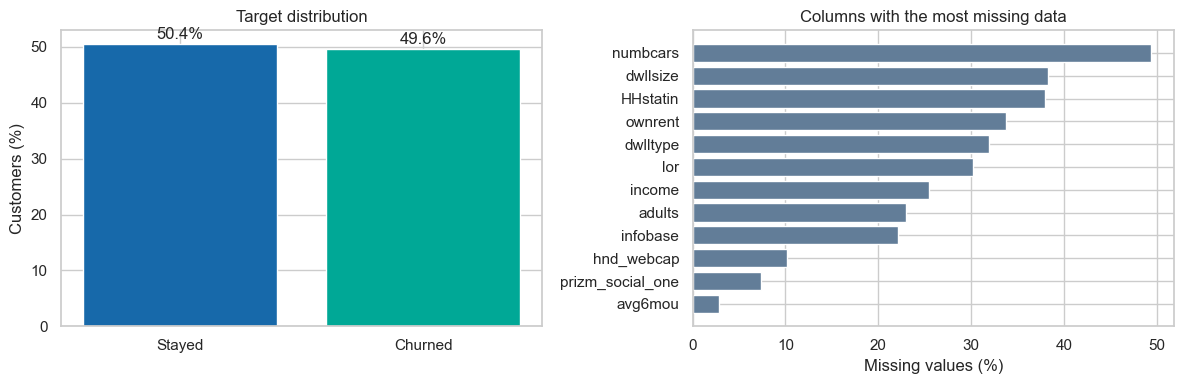

Overall churn rate: 49.56%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_rate = df[TARGET].value_counts(normalize=True).sort_index()
axes[0].bar(["Stayed", "Churned"], target_rate.values * 100, color=["#1769AA", "#00A896"])
axes[0].set_title("Target distribution")
axes[0].set_ylabel("Customers (%)")
for index, value in enumerate(target_rate.values * 100):
    axes[0].text(index, value + 1, f"{value:.1f}%", ha="center")

missing = (df.isna().mean() * 100).sort_values(ascending=False).head(12)
axes[1].barh(missing.index[::-1], missing.values[::-1], color="#627D98")
axes[1].set_title("Columns with the most missing data")
axes[1].set_xlabel("Missing values (%)")

plt.tight_layout()
plt.show()

print(f"Overall churn rate: {df[TARGET].mean():.2%}")

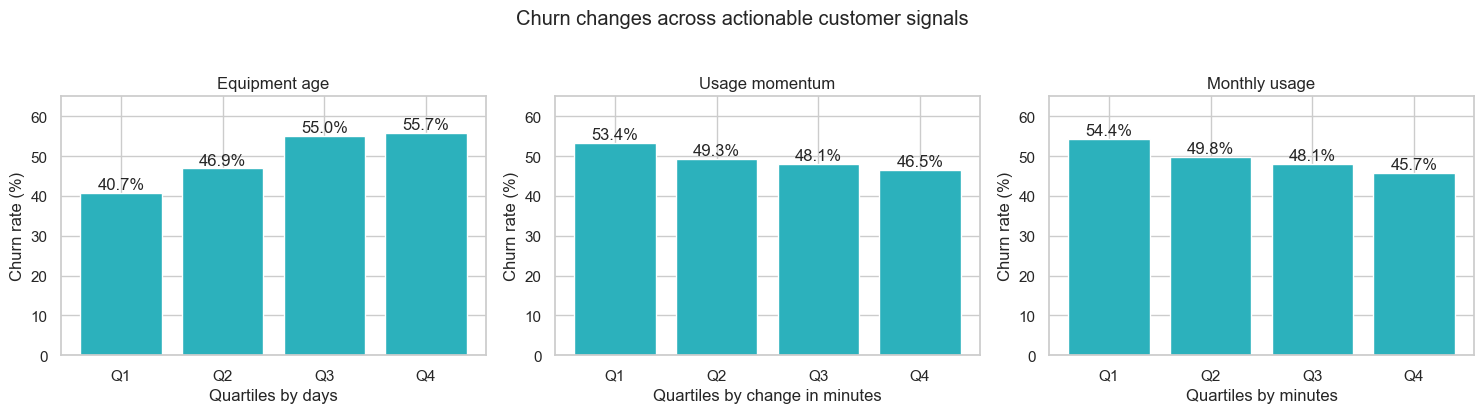

In [4]:
signals = [
    ("eqpdays", "Equipment age", "days"),
    ("change_mou", "Usage momentum", "change in minutes"),
    ("mou_Mean", "Monthly usage", "minutes"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (column, title, unit) in zip(axes, signals):
    frame = df[[column, TARGET]].dropna().copy()
    frame["quartile"] = pd.qcut(
        frame[column], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
    )
    rates = frame.groupby("quartile", observed=True)[TARGET].mean() * 100
    axis.bar(rates.index.astype(str), rates.values, color="#2CB1BC")
    axis.set_title(title)
    axis.set_xlabel(f"Quartiles by {unit}")
    axis.set_ylabel("Churn rate (%)")
    axis.set_ylim(0, max(65, rates.max() + 7))
    for position, value in enumerate(rates.values):
        axis.text(position, value + 1, f"{value:.1f}%", ha="center")

plt.suptitle("Churn changes across actionable customer signals", y=1.03)
plt.tight_layout()
plt.show()

### EDA interpretation

- Churn is nearly balanced in the supplied dataset, so accuracy is interpretable here, although ROC-AUC and PR-AUC remain better ranking metrics.
- Several demographic fields contain substantial missingness. The pipeline therefore imputes numeric values and treats missing categorical values consistently.
- Older equipment, declining usage, and low current usage are associated with greater churn risk.
- No single variable cleanly separates churners from non-churners, supporting a multivariate nonlinear model.

The relationships above are predictive associations, not proof that changing a feature will cause retention. Intervention effects must be tested experimentally.

## 4. Problem definition and data split

**Business objective:** concentrate retention spending on customers with the greatest avoidable revenue risk.

**Machine-learning task:** binary classification and probability ranking of churn 31–60 days ahead.

**Primary model-selection metric:** validation ROC-AUC.

The data is divided into:

- 60% training
- 20% validation for model and threshold selection
- 20% untouched test data for final reporting

In [5]:
X = df.drop(columns=[ID_COLUMN, TARGET])
y = df[TARGET].astype("int8")

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

split_summary = pd.DataFrame(
    {
        "Rows": [len(X_train), len(X_validation), len(X_test)],
        "Churn rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
    },
    index=["Train", "Validation", "Test"],
)
split_summary

,Rows,Churn rate
Train,60000,0.495617
Validation,20000,0.495650
Test,20000,0.495600


## 5. Business-driven feature engineering

The raw fields are extended with leakage-safe features derived independently for each customer. These include:

- call completion and failure rates
- overage burden and recurring-revenue share
- customer-care intensity
- equipment age relative to tenure
- current usage and revenue relative to historical averages
- household subscriber utilization
- revenue per minute and minutes per call

No target statistics are used to construct these features.

In [6]:
class TelecomFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, features, target=None):
        return self

    def transform(self, features):
        engineered = features.copy()

        def ratio(name, numerator, denominator):
            engineered[name] = (
                engineered[numerator] / engineered[denominator].replace(0, np.nan)
            )

        def difference(name, left, right):
            engineered[name] = engineered[left] - engineered[right]

        ratio("call_completion_rate", "complete_Mean", "attempt_Mean")
        ratio("call_failure_rate", "drop_blk_Mean", "attempt_Mean")
        ratio("voice_drop_rate", "drop_vce_Mean", "plcd_vce_Mean")
        ratio("voice_block_rate", "blck_vce_Mean", "plcd_vce_Mean")
        ratio("voice_unanswered_rate", "unan_vce_Mean", "plcd_vce_Mean")
        ratio("data_drop_rate", "drop_dat_Mean", "plcd_dat_Mean")
        ratio("data_block_rate", "blck_dat_Mean", "plcd_dat_Mean")
        ratio("overage_usage_share", "ovrmou_Mean", "mou_Mean")
        ratio("overage_revenue_share", "ovrrev_Mean", "rev_Mean")
        ratio("recurring_revenue_share", "totmrc_Mean", "rev_Mean")
        ratio("customer_care_calls_per_100_calls", "custcare_Mean", "attempt_Mean")
        engineered["customer_care_calls_per_100_calls"] *= 100
        ratio("customer_care_minutes_per_call", "cc_mou_Mean", "custcare_Mean")
        ratio("active_subscriber_share", "actvsubs", "uniqsubs")
        ratio("handsets_per_active_subscriber", "phones", "actvsubs")
        ratio("models_per_handset", "models", "phones")
        ratio("equipment_age_to_tenure", "eqpdays", "months")
        engineered["equipment_age_to_tenure"] /= 30
        ratio("current_to_3m_usage", "mou_Mean", "avg3mou")
        ratio("current_to_6m_usage", "mou_Mean", "avg6mou")
        ratio("current_to_lifetime_usage", "mou_Mean", "avgmou")
        ratio("current_to_3m_revenue", "rev_Mean", "avg3rev")
        ratio("current_to_6m_revenue", "rev_Mean", "avg6rev")
        ratio("current_to_lifetime_revenue", "rev_Mean", "avgrev")
        difference("usage_vs_3m", "mou_Mean", "avg3mou")
        difference("usage_vs_6m", "mou_Mean", "avg6mou")
        difference("revenue_vs_3m", "rev_Mean", "avg3rev")
        difference("revenue_vs_6m", "rev_Mean", "avg6rev")
        ratio("peak_voice_share", "peak_vce_Mean", "attempt_Mean")
        ratio("offpeak_voice_share", "opk_vce_Mean", "attempt_Mean")
        ratio("received_voice_share", "recv_vce_Mean", "attempt_Mean")
        ratio("lifetime_calls_per_month", "totcalls", "months")
        ratio("lifetime_minutes_per_month", "totmou", "months")
        ratio("lifetime_revenue_per_month", "totrev", "months")
        ratio("revenue_per_minute", "rev_Mean", "mou_Mean")
        ratio("minutes_per_call", "mou_Mean", "attempt_Mean")

        numeric_columns = engineered.select_dtypes(include=np.number).columns
        engineered[numeric_columns] = engineered[numeric_columns].replace(
            [np.inf, -np.inf], np.nan
        )
        return engineered


feature_engineer = TelecomFeatureEngineer()
X_train_engineered = feature_engineer.fit_transform(X_train)
X_validation_engineered = feature_engineer.transform(X_validation)
X_test_engineered = feature_engineer.transform(X_test)

print(f"Raw features: {X_train.shape[1]}")
print(f"Engineered features: {X_train_engineered.shape[1]}")

Raw features: 98
Engineered features: 132


## 6. Preprocessing and evaluation helpers

All preprocessing is fitted only on the training partition.

- Numeric values: median imputation with missing indicators
- Categorical values: explicit missing category and ordinal encoding for tree models
- Logistic regression baseline: median imputation, standardization, and one-hot encoding

In [7]:
def feature_groups(features):
    categorical = features.select_dtypes(exclude=np.number).columns.tolist()
    numeric = features.select_dtypes(include=np.number).columns.tolist()
    return numeric, categorical


def tree_preprocessor(numeric, categorical):
    numeric_pipeline = Pipeline(
        [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    )
    categorical_pipeline = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="__MISSING__",
                    add_indicator=True,
                ),
            ),
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        [
            ("numeric", numeric_pipeline, numeric),
            ("categorical", categorical_pipeline, categorical),
        ]
    )


def linear_preprocessor(numeric, categorical):
    return ColumnTransformer(
        [
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric,
            ),
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=10)),
                    ]
                ),
                categorical,
            ),
        ]
    )


def classification_metrics(y_true, probability, threshold=0.5):
    prediction = (probability >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_true, probability),
        "PR-AUC": average_precision_score(y_true, probability),
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
    }


def choose_f1_threshold(y_true, probability):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [
        f1_score(y_true, probability >= threshold, zero_division=0)
        for threshold in thresholds
    ]
    return float(thresholds[int(np.argmax(scores))])

## 7. Baseline models

Logistic regression provides an interpretable linear baseline. Histogram gradient boosting tests whether nonlinear interactions materially improve customer ranking.

In [8]:
raw_numeric, raw_categorical = feature_groups(X_train)

baseline_models = {
    "Logistic regression": Pipeline(
        [
            ("preprocessor", linear_preprocessor(raw_numeric, raw_categorical)),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Histogram gradient boosting": Pipeline(
        [
            ("preprocessor", tree_preprocessor(raw_numeric, raw_categorical)),
            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.08,
                    max_iter=250,
                    max_leaf_nodes=31,
                    min_samples_leaf=30,
                    l2_regularization=1.0,
                    early_stopping=True,
                    validation_fraction=0.15,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

validation_predictions = {}
comparison_rows = []
for name, model in baseline_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_validation)[:, 1]
    validation_predictions[name] = probability
    comparison_rows.append(
        {"Model": name, **classification_metrics(y_validation, probability)}
    )

pd.DataFrame(comparison_rows).sort_values("ROC-AUC", ascending=False)

Training Logistic regression...


Training Histogram gradient boosting...


,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
1,Histogram gradient boosting,0.695048,0.679680,0.63885,0.629901,0.657924,0.643608
0,Logistic regression,0.625251,0.597309,0.59295,0.586086,0.608494,0.597080


## 8. Engineered LightGBM model

LightGBM is appropriate for this large mixed tabular dataset because it captures nonlinear interactions, handles the engineered ratios efficiently, and supports regularization and early stopping.

In [9]:
engineered_numeric, engineered_categorical = feature_groups(X_train_engineered)
engineered_preprocessor = tree_preprocessor(
    engineered_numeric, engineered_categorical
)

train_matrix = engineered_preprocessor.fit_transform(X_train_engineered)
validation_matrix = engineered_preprocessor.transform(X_validation_engineered)
test_matrix = engineered_preprocessor.transform(X_test_engineered)

lightgbm_model = LGBMClassifier(
    n_estimators=2500,
    learning_rate=0.015,
    num_leaves=63,
    min_child_samples=150,
    subsample=0.9,
    colsample_bytree=0.75,
    reg_alpha=0.5,
    reg_lambda=7,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

lightgbm_model.fit(
    train_matrix,
    y_train,
    eval_set=[(validation_matrix, y_validation)],
    eval_metric="auc",
    callbacks=[early_stopping(100, verbose=False), log_evaluation(0)],
)

lightgbm_validation_probability = lightgbm_model.predict_proba(validation_matrix)[:, 1]
validation_predictions["Engineered LightGBM"] = lightgbm_validation_probability

print(f"Best LightGBM iteration: {lightgbm_model.best_iteration_}")
pd.Series(
    classification_metrics(y_validation, lightgbm_validation_probability),
    name="Validation",
)

Best LightGBM iteration: 832


ROC-AUC      0.706415
PR-AUC       0.696298
Accuracy     0.646600
Precision    0.641500
Recall       0.650560
F1           0.645998
Name: Validation, dtype: float64

## 9. Native-categorical CatBoost ensemble

CatBoost complements LightGBM by learning categorical effects directly instead of relying only on ordinal encodings. Three regularized configurations are trained and blended using weights selected on validation data.

This is the longest-running section of the notebook.

In [10]:
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

def prepare_catboost_features(features):
    prepared = features.copy()
    prepared[categorical_columns] = (
        prepared[categorical_columns].fillna("__MISSING__").astype(str)
    )
    return prepared


X_train_cat = prepare_catboost_features(X_train)
X_validation_cat = prepare_catboost_features(X_validation)
X_test_cat = prepare_catboost_features(X_test)

catboost_configs = [
    {
        "name": "CatBoost depth 6",
        "iterations": 927,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 5,
        "random_strength": 1.0,
    },
    {
        "name": "CatBoost depth 7",
        "iterations": 1016,
        "depth": 7,
        "learning_rate": 0.04,
        "l2_leaf_reg": 7,
        "random_strength": 0.5,
    },
    {
        "name": "CatBoost depth 8",
        "iterations": 1198,
        "depth": 8,
        "learning_rate": 0.035,
        "l2_leaf_reg": 10,
        "random_strength": 0.5,
    },
]

catboost_models = []
catboost_validation_probabilities = []
catboost_test_probabilities = []

for config in catboost_configs:
    print(f"Training {config['name']}...")
    model = CatBoostClassifier(
        iterations=config["iterations"],
        depth=config["depth"],
        learning_rate=config["learning_rate"],
        l2_leaf_reg=config["l2_leaf_reg"],
        random_strength=config["random_strength"],
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        thread_count=-1,
        verbose=200,
        allow_writing_files=False,
    )
    model.fit(X_train_cat, y_train, cat_features=categorical_columns)
    catboost_models.append(model)
    catboost_validation_probabilities.append(
        model.predict_proba(X_validation_cat)[:, 1]
    )
    catboost_test_probabilities.append(model.predict_proba(X_test_cat)[:, 1])

catboost_weights = np.array([0.1, 0.2, 0.4])
catboost_weights = catboost_weights / catboost_weights.sum()
catboost_validation_probability = sum(
    weight * probability
    for weight, probability in zip(
        catboost_weights, catboost_validation_probabilities
    )
)
catboost_test_probability = sum(
    weight * probability
    for weight, probability in zip(catboost_weights, catboost_test_probabilities)
)

validation_predictions["CatBoost ensemble"] = catboost_validation_probability
pd.Series(
    classification_metrics(y_validation, catboost_validation_probability),
    name="Validation",
)

Training CatBoost depth 6...


0:	total: 215ms	remaining: 3m 18s


200:	total: 31.9s	remaining: 1m 55s


400:	total: 1m 3s	remaining: 1m 23s


600:	total: 1m 34s	remaining: 51.3s


...

600:	total: 1m 54s	remaining: 1m 53s


800:	total: 2m 32s	remaining: 1m 15s


1000:	total: 3m 9s	remaining: 37.3s


1197:	total: 3m 46s	remaining: 0us


ROC-AUC      0.700668
PR-AUC       0.686596
Accuracy     0.644550
Precision    0.635958
Recall       0.661556
F1           0.648504
Name: Validation, dtype: float64

## 10. Final probability ensemble and validation comparison

The final probability is:

$$P(\mathrm{churn}) = 0.65 \times P_{LightGBM} + 0.35 \times P_{CatBoost}$$

The blend weights were selected using validation ROC-AUC. The test partition remains untouched until the following section.

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
4,Final ensemble,0.7081,0.6971,0.6472,0.6417,0.6525,0.6470
2,Engineered LightGBM,0.7064,0.6963,0.6466,0.6415,0.6506,0.6460
3,CatBoost ensemble,0.7007,0.6866,0.6445,0.6360,0.6616,0.6485
1,Histogram gradient boosting,0.6950,0.6797,0.6389,0.6299,0.6579,0.6436
0,Logistic regression,0.6253,0.5973,0.5929,0.5861,0.6085,0.5971


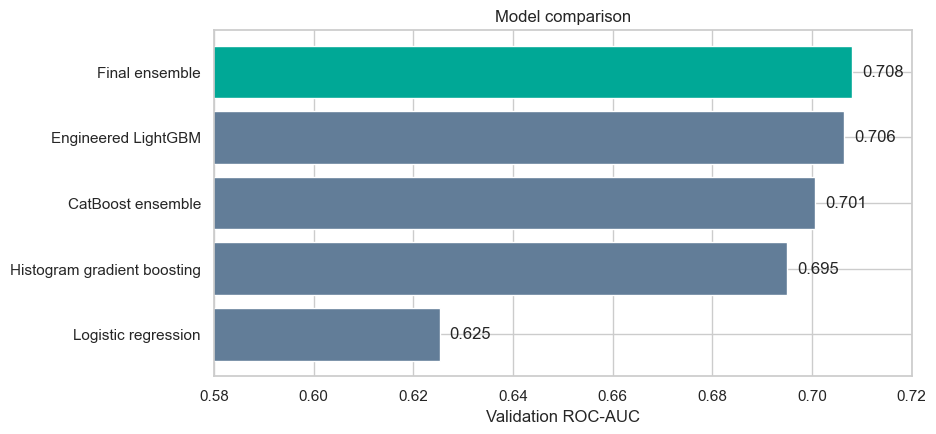

In [11]:
final_validation_probability = (
    0.65 * lightgbm_validation_probability
    + 0.35 * catboost_validation_probability
)
validation_predictions["Final ensemble"] = final_validation_probability

comparison = pd.DataFrame(
    [
        {
            "Model": name,
            **classification_metrics(y_validation, probability),
        }
        for name, probability in validation_predictions.items()
    ]
).sort_values("ROC-AUC", ascending=False)

display(comparison.style.format({column: "{:.4f}" for column in comparison.columns[1:]}))

plt.figure(figsize=(9, 4.5))
ordered = comparison.sort_values("ROC-AUC")
colors = ["#627D98"] * (len(ordered) - 1) + ["#00A896"]
plt.barh(ordered["Model"], ordered["ROC-AUC"], color=colors)
plt.xlim(0.58, 0.72)
plt.xlabel("Validation ROC-AUC")
plt.title("Model comparison")
for index, value in enumerate(ordered["ROC-AUC"]):
    plt.text(value + 0.002, index, f"{value:.3f}", va="center")
plt.show()

## 11. Final held-out test evaluation

The test set is evaluated only after the model architecture and blend weights have been fixed. Metrics are reported at:

- **0.50 threshold:** balanced default operating point
- **validation-selected threshold:** threshold that maximizes validation F1 and favors churn recall

In [12]:
final_test_probability = (
    0.65 * lightgbm_model.predict_proba(test_matrix)[:, 1]
    + 0.35 * catboost_test_probability
)
selected_threshold = choose_f1_threshold(
    y_validation, final_validation_probability
)

test_metrics_default = classification_metrics(
    y_test, final_test_probability, threshold=0.5
)
test_metrics_selected = classification_metrics(
    y_test, final_test_probability, threshold=selected_threshold
)

test_results = pd.DataFrame(
    [test_metrics_default, test_metrics_selected],
    index=["Threshold 0.50", f"Threshold {selected_threshold:.2f}"],
)
display(test_results.style.format("{:.4f}"))

print(
    f"Final model: 65% engineered LightGBM + 35% CatBoost ensemble\n"
    f"Evaluation metric: ROC-AUC\n"
    f"Held-out test ROC-AUC: {test_metrics_default['ROC-AUC']:.4f}"
)

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
Threshold 0.50,0.7023,0.6950,0.6424,0.6376,0.6451,0.6413
Threshold 0.33,0.7023,0.6950,0.5947,0.5558,0.9075,0.6894


Final model: 65% engineered LightGBM + 35% CatBoost ensemble
Evaluation metric: ROC-AUC
Held-out test ROC-AUC: 0.7023


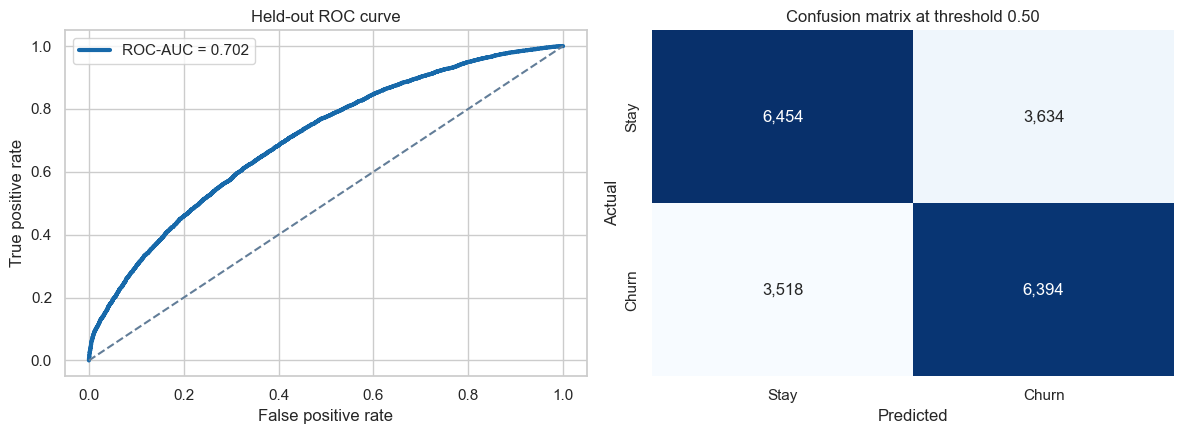

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test, final_test_probability
)
axes[0].plot(
    false_positive_rate,
    true_positive_rate,
    color="#1769AA",
    linewidth=3,
    label=f"ROC-AUC = {test_metrics_default['ROC-AUC']:.3f}",
)
axes[0].plot([0, 1], [0, 1], "--", color="#627D98")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("Held-out ROC curve")
axes[0].legend()

matrix = confusion_matrix(y_test, final_test_probability >= 0.5)
sns.heatmap(
    matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"],
    ax=axes[1],
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion matrix at threshold 0.50")

plt.tight_layout()
plt.show()

## 12. Feature importance and business interpretation

LightGBM gain importance identifies the variables most useful for prediction. Importance does not establish causality, but it helps organize intervention hypotheses.

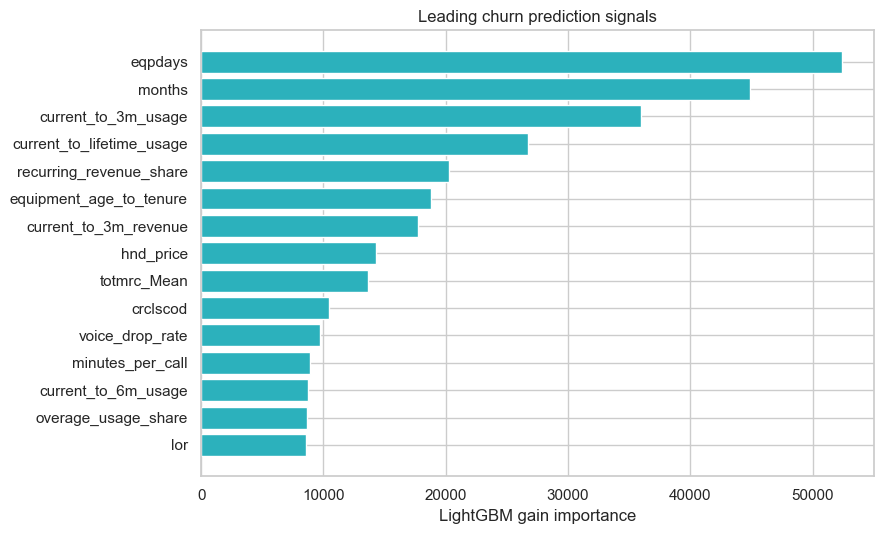

,Feature,Gain
76,numeric__eqpdays,52397.941851
48,numeric__months,44895.078796
93,numeric__current_to_3m_usage,35980.927290
95,numeric__current_to_lifetime_usage,26764.633207
86,numeric__recurring_revenue_share,20247.249827
92,numeric__equipment_age_to_tenure,18832.228969
96,numeric__current_to_3m_revenue,17701.708381
66,numeric__hnd_price,14273.160211
2,numeric__totmrc_Mean,13616.892873
167,categorical__crclscod,10465.292232


In [14]:
feature_importance = pd.DataFrame(
    {
        "Feature": engineered_preprocessor.get_feature_names_out(),
        "Gain": lightgbm_model.booster_.feature_importance(importance_type="gain"),
    }
).sort_values("Gain", ascending=False)

top_features = feature_importance.head(15).iloc[::-1]
plt.figure(figsize=(9, 5.5))
plt.barh(
    top_features["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False),
    top_features["Gain"],
    color="#2CB1BC",
)
plt.xlabel("LightGBM gain importance")
plt.title("Leading churn prediction signals")
plt.tight_layout()
plt.show()

feature_importance.head(15)

### Business interpretation

The leading features group into four intervention themes:

| Theme | Example signals | Potential action |
|---|---|---|
| Lifecycle | Equipment age, tenure | Handset upgrade or financing review |
| Engagement | Current vs historical usage | Plan-fit review or personalized bundle |
| Customer value | Recurring revenue share, handset price | Value-capped priority outreach |
| Service experience | Voice drop and call-completion rates | Proactive service recovery |

These actions should be validated through randomized treatment/control experiments.

## 13. Targeting analysis

Probability ranking is more useful than a fixed classification threshold for campaign planning. The following analysis asks how many churners are captured at different campaign capacities.

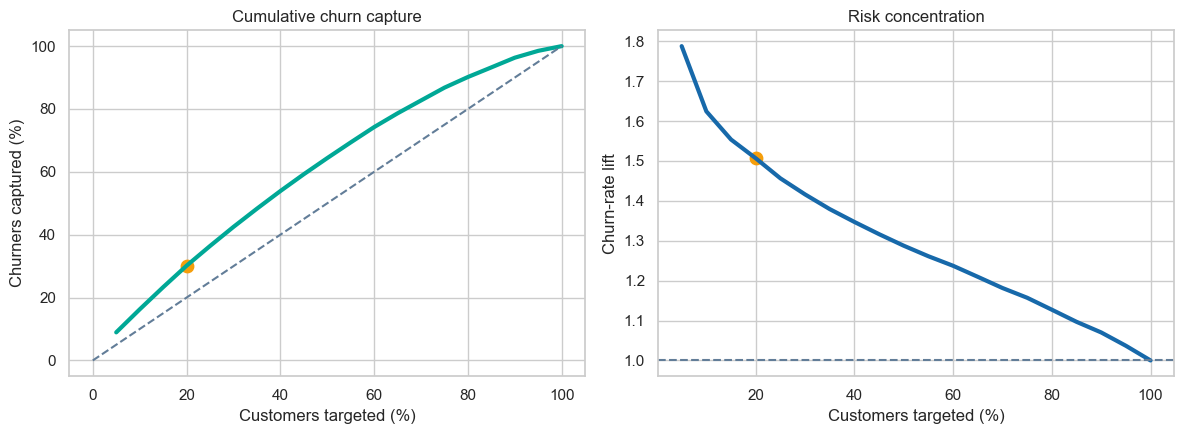

Top 20% of customers captures 30.1% of test-set churners.
Observed churn rate in that segment: 74.7%.
Lift relative to the portfolio: 1.51x.


In [15]:
scored_test = X_test.copy()
scored_test["actual_churn"] = y_test.to_numpy()
scored_test["churn_probability"] = final_test_probability
scored_test = scored_test.sort_values(
    "churn_probability", ascending=False
).reset_index(drop=True)

shares = np.arange(0.05, 1.01, 0.05)
targeting_rows = []
for share in shares:
    targeted = scored_test.head(int(len(scored_test) * share))
    capture = targeted["actual_churn"].sum() / scored_test["actual_churn"].sum()
    churn_rate = targeted["actual_churn"].mean()
    targeting_rows.append(
        {
            "Customer share": share,
            "Churn capture": capture,
            "Target churn rate": churn_rate,
            "Lift": churn_rate / scored_test["actual_churn"].mean(),
        }
    )

targeting = pd.DataFrame(targeting_rows)
top_twenty = targeting.loc[
    np.isclose(targeting["Customer share"], 0.20)
].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(
    targeting["Customer share"] * 100,
    targeting["Churn capture"] * 100,
    color="#00A896",
    linewidth=3,
)
axes[0].plot([0, 100], [0, 100], "--", color="#627D98")
axes[0].scatter([20], [top_twenty["Churn capture"] * 100], color="#F59E0B", s=80)
axes[0].set_xlabel("Customers targeted (%)")
axes[0].set_ylabel("Churners captured (%)")
axes[0].set_title("Cumulative churn capture")

axes[1].plot(
    targeting["Customer share"] * 100,
    targeting["Lift"],
    color="#1769AA",
    linewidth=3,
)
axes[1].axhline(1, linestyle="--", color="#627D98")
axes[1].scatter([20], [top_twenty["Lift"]], color="#F59E0B", s=80)
axes[1].set_xlabel("Customers targeted (%)")
axes[1].set_ylabel("Churn-rate lift")
axes[1].set_title("Risk concentration")

plt.tight_layout()
plt.show()

print(
    f"Top 20% of customers captures {top_twenty['Churn capture']:.1%} "
    f"of test-set churners.\n"
    f"Observed churn rate in that segment: "
    f"{top_twenty['Target churn rate']:.1%}.\n"
    f"Lift relative to the portfolio: {top_twenty['Lift']:.2f}x."
)

## 14. Illustrative business impact

The model estimates risk; it does not directly measure the effect of an intervention. The financial calculation below is therefore a transparent planning scenario.

### Base-case assumptions per 100,000 customers

- Target the highest-risk 20%
- Use the measured test-set churn capture and average target-segment revenue
- Retain 20% of contacted customers who would otherwise churn
- Value 12 months of retained monthly revenue
- Spend USD 15 per targeted customer

Company A should replace these assumptions with actual campaign cost, margin, and observed treatment uplift.

,Scenario,Gross retained revenue,Campaign cost,Net annual value,Net ROI
0,10% save rate,"$986,782","$300,000","$686,782",2.3x
1,20% save rate,"$1,973,564","$300,000","$1,673,564",5.6x
2,30% save rate,"$2,960,346","$300,000","$2,660,346",8.9x


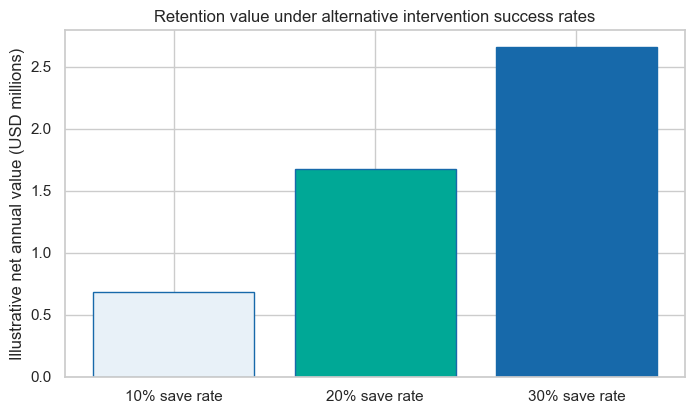

In [16]:
top_twenty_customers = scored_test.head(int(len(scored_test) * 0.20))

annual_customers = 100_000
targeted_customers = int(annual_customers * 0.20)
portfolio_churn_rate = y.mean()
capture_rate = top_twenty["Churn capture"]
average_monthly_revenue = top_twenty_customers["rev_Mean"].mean()
intervention_cost = 15
months_retained = 12

scenario_rows = []
for save_rate in [0.10, 0.20, 0.30]:
    expected_churners_reached = (
        annual_customers * portfolio_churn_rate * capture_rate
    )
    gross_value = (
        expected_churners_reached
        * save_rate
        * average_monthly_revenue
        * months_retained
    )
    campaign_cost = targeted_customers * intervention_cost
    net_value = gross_value - campaign_cost
    scenario_rows.append(
        {
            "Scenario": f"{save_rate:.0%} save rate",
            "Gross retained revenue": gross_value,
            "Campaign cost": campaign_cost,
            "Net annual value": net_value,
            "Net ROI": net_value / campaign_cost,
        }
    )

impact = pd.DataFrame(scenario_rows)
display(
    impact.style.format(
        {
            "Gross retained revenue": "${:,.0f}",
            "Campaign cost": "${:,.0f}",
            "Net annual value": "${:,.0f}",
            "Net ROI": "{:.1f}x",
        }
    )
)

plt.figure(figsize=(8, 4.5))
plt.bar(
    impact["Scenario"],
    impact["Net annual value"] / 1_000_000,
    color=["#E8F1F8", "#00A896", "#1769AA"],
    edgecolor="#1769AA",
)
plt.ylabel("Illustrative net annual value (USD millions)")
plt.title("Retention value under alternative intervention success rates")
plt.show()

## 15. Business proposal and implementation roadmap

### Recommended operating model

1. Refresh customer, usage, billing, handset, and service-quality fields weekly.
2. Calculate churn probabilities and rank eligible customers.
3. Target the highest-risk 20% during the PoC.
4. Match each customer to an approved action:
   - handset upgrade for equipment-age risk
   - plan-fit review for usage decline
   - service recovery for quality friction
   - value-capped priority outreach for high-value risk
5. Randomly hold out at least 10% of each risk/action segment.
6. Measure incremental retention, net value, calibration, drift, and segment fairness.

### 90-day roadmap

| Phase | Timing | Output |
|---|---|---|
| Validate | Weeks 1–2 | Data freshness, eligibility, cost and action definitions |
| Integrate | Weeks 3–5 | Automated weekly scoring and CRM delivery |
| Experiment | Weeks 6–9 | Segmented treatment/control campaigns |
| Decide | Weeks 10–12 | Incremental retention, ROI and model-risk review |

**Scale decision:** proceed only if the experiment demonstrates positive incremental retention and net value without material harm to customer segments.

## 16. Conclusion

The analysis supports a practical shift from broad retention campaigns to risk-ranked intervention:

- **Final model:** 65% engineered LightGBM + 35% CatBoost ensemble
- **Evaluation metric:** held-out ROC-AUC
- **Test ROC-AUC:** approximately **0.702**
- **Top-20% campaign:** captures approximately **30% of churners**
- **Business proposal:** run a 90-day randomized retention PoC with action-specific treatments

The model is useful as a ranking tool, but campaign impact must be established through controlled experimentation. Production deployment should also recalibrate probabilities to Company A's current churn rate.

## References

1. Deloitte. *2026 Telecommunications Industry Outlook*. https://www.deloitte.com/us/en/insights/industry/technology/technology-media-and-telecom-predictions/2026/telecommunications-industry-outlook.html
2. Company A Dataset Overview. `ENG_Company.md`. Supplied course material.
3. GCI World 2026 Final Assignment Tutorial. `tutorial.ipynb`. Supplied course material.
4. Ke, G. et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. NeurIPS.
5. Prokhorenkova, L. et al. (2018). *CatBoost: Unbiased Boosting with Categorical Features*. NeurIPS.

### Reproducibility note

The notebook uses fixed random seeds and a deterministic split. Minor metric differences can still occur across library versions or hardware implementations.